# Anatomie d'un marché : Airbnb au microscope
**Problématiques** : Le statut Superhost d'un hôte a-t-il un effet causal sur le prix de son logement ?

## Setup global — imports, couleurs pastel, seed

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
import scipy.stats as stats


In [9]:
SEED = 5

In [10]:
PASTEL = {
    'rose':    '#FFB3BA',
    'peche':   '#FFDFBA',
    'jaune':   '#FFFFBA',
    'vert':    '#BAFFC9',
    'bleu':    '#BAE1FF',
    'violet':  '#E8BAFF',
    'gris':    '#D9D9D9',
    'corail':  '#FFABAB',
    'menthe':  '#B5EAD7',
    'lavande': '#C9C0FF',
}
ROOM_COLORS  = ['#FFB3BA','#BAE1FF','#BAFFC9','#FFFFBA']
SH_COLORS    = {'Superhost':'#BAFFC9','Non-Superhost':'#FFB3BA'}
PASTEL_LIST  = list(PASTEL.values())

sns.set_theme(style='whitegrid', palette=PASTEL_LIST)
plt.rcParams.update({'figure.dpi':100, 'axes.titlesize':13, 'axes.labelsize':11})

print("pass")


pass


## Chargement et nettoyage des données

In [11]:
import pandas as pd

df = pd.read_csv('./Data/listings.csv')

df['price'] = df['price'].str.replace('$', '')
df['price'] = df['price'].str.replace(',', '')
df['price'] = pd.to_numeric(df['price'], errors='coerce')

df['price'] = df['price'] / 100


df['host_is_superhost'] = df['host_is_superhost'].replace('t', '1')
df['host_is_superhost'] = df['host_is_superhost'].replace('f', '0')

df['host_is_superhost'] = pd.to_numeric(df['host_is_superhost'], errors='coerce')
today = pd.Timestamp.today()

df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
today = pd.Timestamp.today()
df['anciennete'] = (today - df['host_since']).dt.days

def groupe_avis(x):
    if x == 0:
        return '0 avis'
    elif x <= 5:
        return '1-5 avis'
    else:
        return '5+ avis'

df['nombre_avis_groupe'] = df['number_of_reviews'].apply(groupe_avis)


df = df[df['price'].notna()]
df = df[df['price'] > 0]

limite = df['price'].quantile(0.99)
df = df[df['price'] < limite]

print("Lignes après nettoyage :", len(df))
print("Prix médian :", df['price'].median())
print("Prix moyen :", df['price'].mean())
df.head()

Lignes après nettoyage : 25225
Prix médian : 160.65
Prix moyen : 204.80271040634292


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,anciennete,nombre_avis_groupe
0,197677,https://www.airbnb.com/rooms/197677,20250929042135,2025-09-30,city scrape,Oshiage Holiday Apartment,NaN,NaN,https://a0.muscache.com/pictures/38437056/d27f...,964081,...,4.80,M130003350,f,1,1,0,0,1.11,5319.0,5+ avis
1,776070,https://www.airbnb.com/rooms/776070,20250929042135,2025-09-29,city scrape,Kero-kero room 1F,We have been in airbnb since 2011 and it has g...,We love Nishinippori because is nearer to Toky...,https://a0.muscache.com/pictures/efd9f039-dbd2...,801494,...,4.92,M130000243,f,1,0,1,0,1.74,5353.0,5+ avis
2,905944,https://www.airbnb.com/rooms/905944,20250929042135,2025-09-29,city scrape,4F Spacious Apartment in Shinjuku / Shibuya Tokyo,NEWLY RENOVATED property entirely for you & yo...,Hatagaya is a great neighborhood located 4 min...,https://a0.muscache.com/pictures/hosting/Hosti...,4847803,...,4.81,Hotels and Inns Business Act | 渋谷区保健所長 | 31渋健生...,t,9,9,0,0,1.85,4788.0,5+ avis
3,1016831,https://www.airbnb.com/rooms/1016831,20250929042135,2025-09-29,city scrape,5 mins Shibuya Cat modern sunny Shimokita,"Hi there, I am Wakana and I live with my two f...",The location is walkable distance to famous Sh...,https://a0.muscache.com/pictures/airflow/Hosti...,5596383,...,4.89,M130001107,f,1,0,1,0,1.87,4730.0,5+ avis
4,1196177,https://www.airbnb.com/rooms/1196177,20250929042135,2025-09-29,city scrape,Homestay at Host's House - Senju-Ohashi Station,Our accommodation offers: <br /><br />1. **Gr...,There are shopping mall near Senjuohashi stati...,https://a0.muscache.com/pictures/72890882/05ec...,5686404,...,4.83,M130007760,f,1,0,1,0,1.01,4724.0,5+ avis



# Phase 1 — Causalité et biais
*Modèle de Rubin, DAGs, Simpson, Bootstrapping, PSM*

## 1.1 Identification et quantification des biais
**Ce qu'on cherche** : vérifier si les 3 groupes (0 avis / 1-5 / 5+) représentent la même population en termes de prix.

### Biais de selection

In [12]:
stats_biais = (
    df.groupby('nombre_avis_groupe')['price']
      .agg(n='count', Médiane='median', Moyenne='mean', Écart_type='std')
)

print(stats_biais.round(1))

groups = [g['price'].values for _, g in df.groupby('nombre_avis_groupe')]
stat, p = stats.kruskal(*groups)

print(f"\nKruskal-Wallis : H={stat:.2f}, p={p:.2e}")

                        n  Médiane  Moyenne  Écart_type
nombre_avis_groupe                                     
0 avis               3313    149.6    202.1       167.2
1-5 avis             4849    147.6    193.4       147.0
5+ avis             17063    167.3    208.6       147.5

Kruskal-Wallis : H=144.46, p=4.28e-32


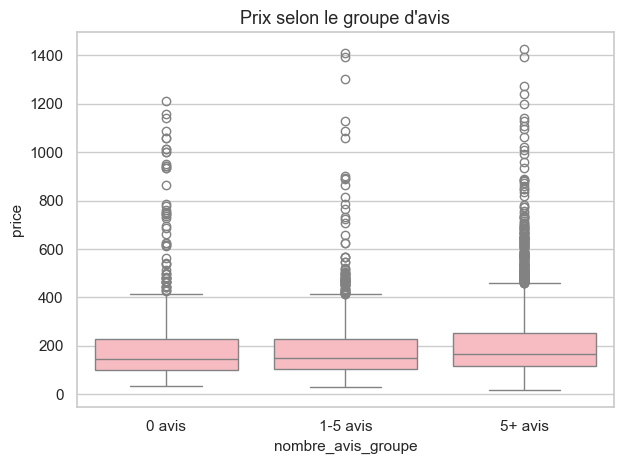

In [13]:
sample = df.sample(min(5000, len(df)), random_state=SEED)

sns.boxplot(
    data=sample,
    x='nombre_avis_groupe',
    y='price',
    order=['0 avis','1-5 avis','5+ avis']
)

plt.title("Prix selon le groupe d'avis")
plt.tight_layout()
plt.show()

**ANALYSE** : Les trois groupes montrent des distributions de prix différentes. La présence ou l'absence d'avis est corrélée au prix, ce qui suggère un biais de sélection : les listings inactifs (0 avis) ne représentent pas la même population que les listings actifs. Le test de Kruskal-Wallis confirme que les différences sont statistiquement significatives.

### Biais de survivorship

In [14]:
nb_total    = len(df)
nb_actifs   = (df['number_of_reviews'] > 0).sum()
nb_inactifs = (df['number_of_reviews'] == 0).sum()
prix_actifs   = df.loc[df['number_of_reviews'] > 0, 'price'].median()
prix_inactifs = df.loc[df['number_of_reviews'] == 0, 'price'].median()

print(f"Total listings    : {nb_total:,}")
print(f"Actifs : {nb_actifs:,}  ({100*nb_actifs/nb_total:.1f}%)")
print(f"Inactifs (: {nb_inactifs:,}  ({100*nb_inactifs/nb_total:.1f}%)")
print(f"Prix médian actifs   : {prix_actifs:.0f}")
print(f"Prix médian inactifs : {prix_inactifs:.0f}")


Total listings    : 25,225
Actifs : 21,912  (86.9%)
Inactifs (: 3,313  (13.1%)
Prix médian actifs   : 162
Prix médian inactifs : 150


**ANALYSE** : Le dataset ne contient que les listings encore visibles aujourd'hui. Les logements qui ont quitté la plateforme (supprimés pour mauvaises performances ou prix trop élevé) sont absents, ce qui surestime probablement le prix moyen du marché.

### Biais de mesure — Bootstrapping sur corrélation avis/prix

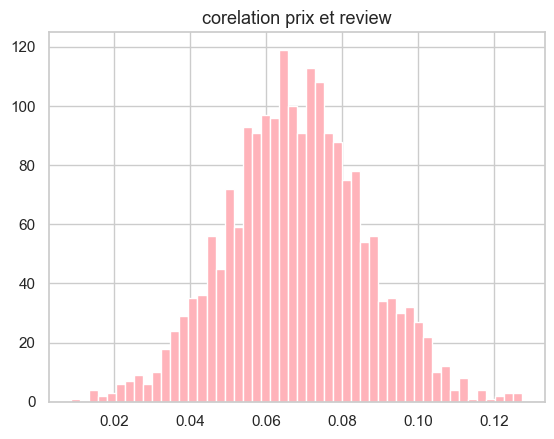

In [15]:
sub = df[['number_of_reviews','price']].dropna().sample(3000, random_state=SEED)

boot = np.array([
    sub.sample(frac=1, replace=True).corr().iloc[0,1]
    for _ in range(2000)
])

ci = np.percentile(boot, [2.5, 97.5])
plt.title("corelation prix et review")
plt.hist(boot, bins=50)
plt.show()

**ANALYSE** : r ≈ 0.06 bootstrap très resserré → pas un proxy fiable, relation trop faible.

## 1.2 Construction du DAG causal
**Ce qu'on cherche** :a construire un dag pour expliquer les corrélations entre chaque variable 

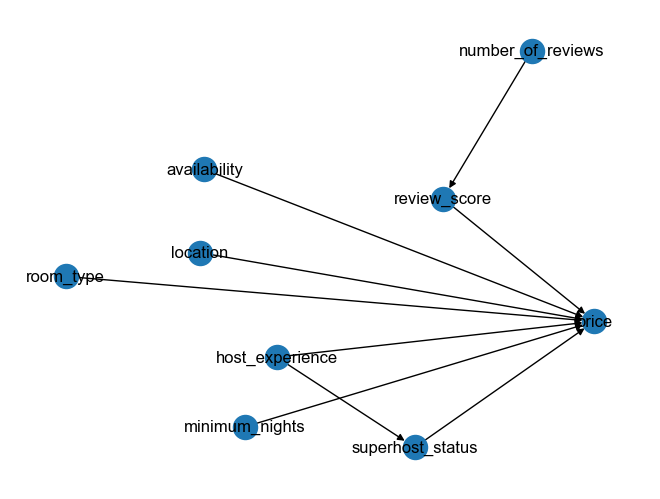

In [16]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph([
    ('host_experience','superhost_status'),
    ('host_experience','price'),
    ('location','price'),
    ('room_type','price'),
    ('number_of_reviews','review_score'),
    ('review_score','price'),
    ('superhost_status','price'),
    ('availability','price'),
    ('minimum_nights','price')
])

pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True)

plt.show()

host_experience : plus l'hôte est expérimenté, plus il a de chances d'être superhost et de fixer un bon prix
superhost_status : variable qu'on cherche à expliquer — est-ce qu'être superhost fait monter le prix ?
location : le quartier influence directement le prix
room_type : le type de logement influence directement le prix
review_score : la note est influencée par les avis et impacte le prix
number_of_reviews : le volume d'avis influence la note
availability : la disponibilité du listing influence le prix
minimum_nights : la durée minimale de séjour influence le prix

**ANALYSE** : 3 backdoor paths : expérience hôte, note moyenne, arrondissement. Notes et avis sont médiateurs — ne pas les contrôler pour isoler l'effet causal.

## 1.3 Détection d'un paradoxe de Simpson
**Ce qu'on cherche** : la corrélation globale entre nombre d'avis et prix

In [17]:
corr_global = df['number_of_reviews'].corr(df['price'])
print(f"Corrélation globale : {corr_global:.4f}\n")


for room_type, subset in df.groupby('room_type'):
    reviews = subset['number_of_reviews']
    prices = subset['price']
    corr = reviews.corr(prices)
    
    print(f"{room_type:<25} r = {corr:.4f} (n={len(subset):,})")

Corrélation globale : 0.0281

Entire home/apt           r = 0.0581 (n=21,841)
Hotel room                r = -0.0998 (n=87)
Private room              r = -0.0641 (n=3,043)
Shared room               r = -0.0342 (n=254)


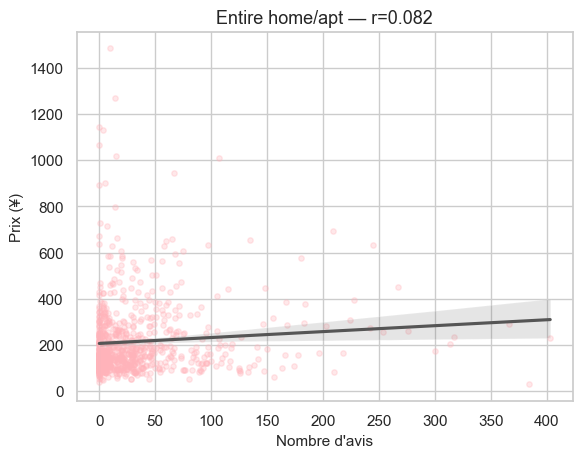

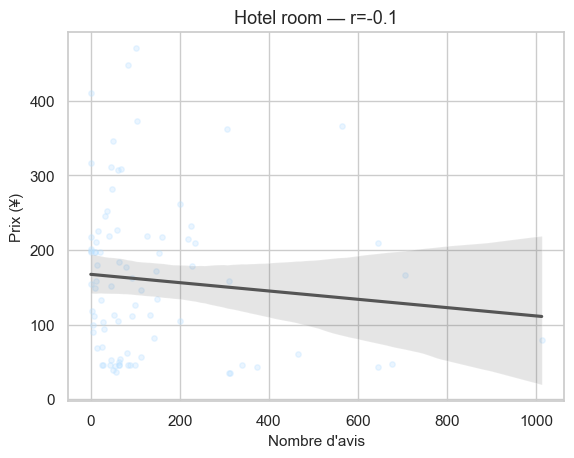

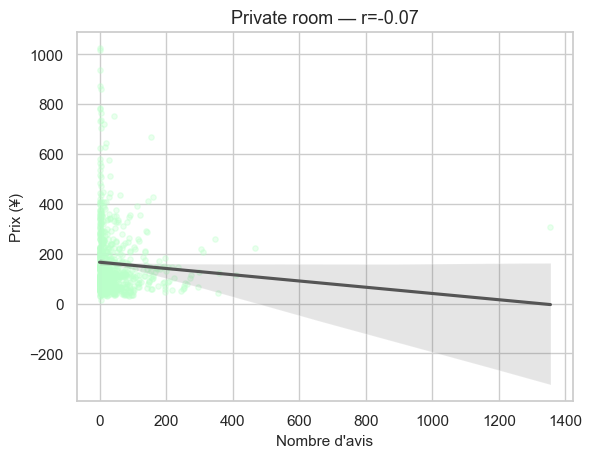

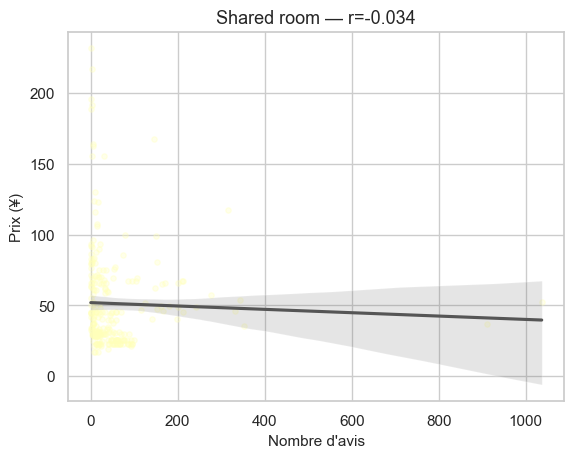

In [23]:

for rt, col in zip(sorted(df['room_type'].dropna().unique()), ROOM_COLORS):
    sub = df[df['room_type'] == rt]
    if len(sub) > 800:
        sub = sub.sample(800, random_state=SEED)
    sns.regplot(
        x='number_of_reviews',
        y='price',
        data=sub,
        scatter_kws={'s':15, 'alpha':0.3, 'color':col},
        line_kws={'color':'#555'}
    )

    corr = sub['number_of_reviews'].corr(sub['price'])
    plt.title(rt + " — r=" + str(round(corr, 3)))
    plt.xlabel("Nombre d'avis")
    plt.ylabel("Prix (¥)")
    plt.show()

In [ ]:
room_types = sorted(df['room_type'].dropna().unique())

print("Corrélation number_of_reviews ~ price par room_type :")

for rt in room_types:
    sub = df[df['room_type'] == rt]
    corr = sub['number_of_reviews'].corr(sub['price'])
    n = len(sub)

    print(f"{rt}  r = {corr:.4f}  (n = {n})")

Corrélation number_of_reviews ~ price par room_type :
Entire home/apt  r = 0.0581  (n = 21841)
Hotel room  r = -0.0998  (n = 87)
Private room  r = -0.0641  (n = 3043)
Shared room  r = -0.0342  (n = 254)


**ANALYSE**: Le renversement de corrélation est un Paradoxe de Simpson causé par le confounder room_type, qui masque la relation réelle entre number_of_reviews et price.

## 1.4 Propensity Score Matching
**Ce qu'on cherche** : estimer l'effet causal du statut Superhost sur le prix en contrôlant les confounders.

In [26]:

psm_df = df[['host_is_superhost','price','anciennete','review_scores_rating',
             'neighbourhood_cleansed','room_type']]

psm_df = psm_df.dropna()

psm_df = psm_df[psm_df['price'] > 0]

psm_df = pd.get_dummies(psm_df, columns=['neighbourhood_cleansed','room_type'], drop_first=True)
X_psm = psm_df.drop(['host_is_superhost','price'], axis=1)
y_psm = psm_df['host_is_superhost']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_psm)


lr = LogisticRegression(max_iter=500, random_state=SEED)
lr.fit(X_scaled, y_psm)
psm_df['propensity_score'] = lr.predict_proba(X_scaled)[:,1]

print("Nombre de traités :", (y_psm==1).sum())
print("Nombre de contrôles :", (y_psm==0).sum())
print("Propensity score médian pour les traités :", psm_df.loc[y_psm==1,'propensity_score'].median())
print("Propensity score médian pour les contrôles :", psm_df.loc[y_psm==0,'propensity_score'].median())

Nombre de traités : 9695
Nombre de contrôles : 10604
Propensity score médian pour les traités : 0.5988046209046639
Propensity score médian pour les contrôles : 0.39463379441995805


In [27]:

traites  = psm_df[psm_df['host_is_superhost']==1].copy()
controles = psm_df[psm_df['host_is_superhost']==0].copy()

CALIPER = 0.05
matched_ctrl_idx = []
used = set()           

for idx, row in traites.iterrows():
    diff = (controles['propensity_score'] - row['propensity_score']).abs()
    diff = diff[~diff.index.isin(used)]
    
    if diff.empty:
        matched_ctrl_idx.append(None)
        continue
    best = diff.idxmin()
    
    if diff[best] <= CALIPER:
        matched_ctrl_idx.append(best)
        used.add(best)
    else:
        matched_ctrl_idx.append(None)

traites['matched_ctrl'] = matched_ctrl_idx

traites_ok = traites.dropna(subset=['matched_ctrl']).copy()
controles_ok = controles.loc[traites_ok['matched_ctrl']].copy()
att = traites_ok['price'].mean() - controles_ok['price'].mean()

print(f"Traités appariés : {len(traites_ok):,} / {len(traites):,}")
print(f"ATT estimé: {att:.0f} ")

Traités appariés : 6,225 / 9,695
ATT estimé: 30 


**Analyse** Après avoir apparié les Superhosts avec des logements comparables (selon le propensity score), les Superhosts ont en moyenne un prix plus élevé de 30 ou Yenn car c'est au japon  que les contrôles.

In [29]:
psm_df2 = df[['host_is_superhost','price','anciennete','review_scores_rating',
              'neighbourhood_cleansed','room_type']].dropna().copy()
psm_df2 = psm_df2[psm_df2['price'] > 0]
psm_df2 = pd.get_dummies(psm_df2, columns=['neighbourhood_cleansed','room_type'], drop_first=True)

covariates = [c for c in psm_df2.columns if c not in ['host_is_superhost', 'price']]

traites2  = psm_df2[psm_df2['host_is_superhost']==1]
controles2 = psm_df2[psm_df2['host_is_superhost']==0]
controles2_ok = controles2.loc[traites_ok['matched_ctrl']]

smd_rows = []
for col in covariates:
    avant = (traites2[col].mean() - controles2[col].mean()) / (np.sqrt((traites2[col].std()**2 + controles2[col].std()**2) / 2))
    apres = (traites_ok[col].mean() - controles2_ok[col].mean()) / (np.sqrt((traites_ok[col].std()**2 + controles2_ok[col].std()**2) / 2))
    smd_rows.append({'variable': col, 'SMD_avant': avant, 'SMD_apres': apres})

smd_data = pd.DataFrame(smd_rows)

C:\Users\LEOPO\AppData\Local\Temp\ipykernel_39708\386723656.py:15: RuntimeWarning: invalid value encountered in scalar divide
  apres = (traites_ok[col].mean() - controles2_ok[col].mean()) / (np.sqrt((traites_ok[col].std()**2 + controles2_ok[col].std()**2) / 2))


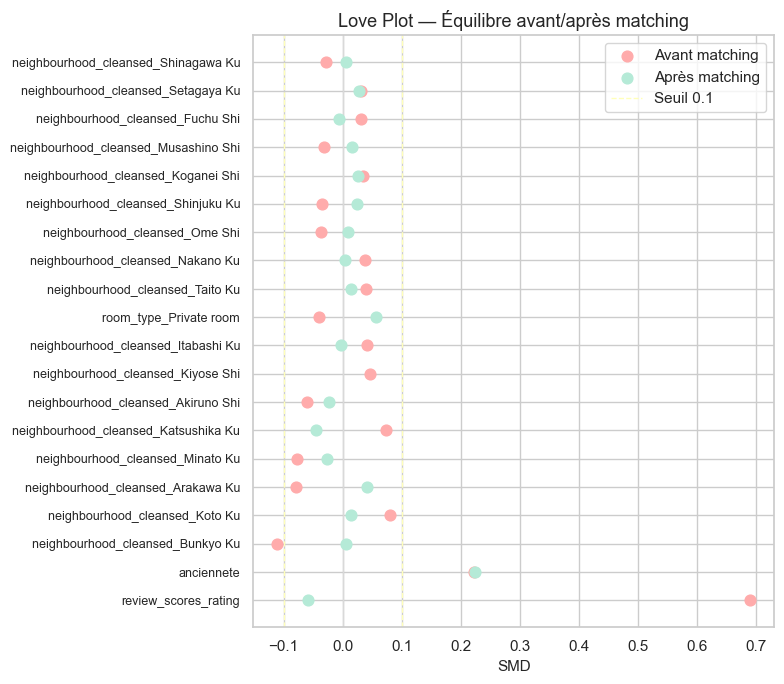

In [30]:
top20 = smd_data.reindex(smd_data['SMD_avant'].abs().nlargest(20).index)

fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(top20['SMD_avant'], range(len(top20)), 
           color=PASTEL['corail'], s=60, label='Avant matching', zorder=3)
ax.scatter(top20['SMD_apres'], range(len(top20)), 
           color=PASTEL['menthe'], s=60, label='Après matching', zorder=3)

ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['variable'], fontsize=9)
ax.axvline(0, color=PASTEL['gris'], linewidth=1)
ax.axvline(0.1, color=PASTEL['jaune'], linewidth=1, linestyle='--', label='Seuil 0.1')
ax.axvline(-0.1, color=PASTEL['jaune'], linewidth=1, linestyle='--')

ax.set_xlabel("SMD")
ax.set_title("Love Plot — Équilibre avant/après matching")
ax.legend()
plt.tight_layout()
plt.show()

**ANALYSE** : Le matching équilibre correctement les variables géographiques et le room_type, mais review_scores_rating (SMD ≈ 0.7) et anciennete (SMD ≈ 0.25) restent mal appariées, ce qui invite à interpréter l'ATT de +30€ avec prudence.

---
# Phase 2 — Visualisation haute dimension
*Réduction dimensionnelle, PCA, UMAP, visualisations spécialisées*

## 2.1 Sélection des features numériques
**Ce qu'on cherche** : réduire les 75 colonnes à 15-20 variables pertinentes.

In [33]:
features_num = [
    'price','accommodates','bathrooms','bedrooms','beds',
    'host_listings_count',
    'minimum_nights','availability_365',
    'number_of_reviews','reviews_per_month',
    'review_scores_rating','review_scores_cleanliness',
    'review_scores_location','review_scores_value',
    'host_is_superhost',
]

df_feat = df[features_num].copy()

imputer_pca = SimpleImputer(strategy='median')
scaler_pca  = StandardScaler()

X_imp_pca    = imputer_pca.fit_transform(df_feat)
X_scaled_pca = scaler_pca.fit_transform(X_imp_pca)

print(f"Shape matrice features : {X_scaled_pca.shape}")

Shape matrice features : (25225, 15)


**ANALYSE** : Les variables exclues sont les identifiants (id, host_id), les variables calendaires redondantes, et les colonnes avec > 80% de valeurs manquantes. De plus, les variables sur une courte période comme les disponibilités calendaires n'apportaient qu'une information ponctuelle et contenaient beaucoup de valeurs manquantes, les rendant inutiles.

## 2.2 PCA exploratoire
**Ce qu'on cherche** : comprendre la structure globale de variance et quelles variables dominent chaque axe principal.

In [34]:
pca = PCA(random_state=SEED)
X_pca = pca.fit_transform(X_scaled_pca)

Composantes pour 80% de variance : 8


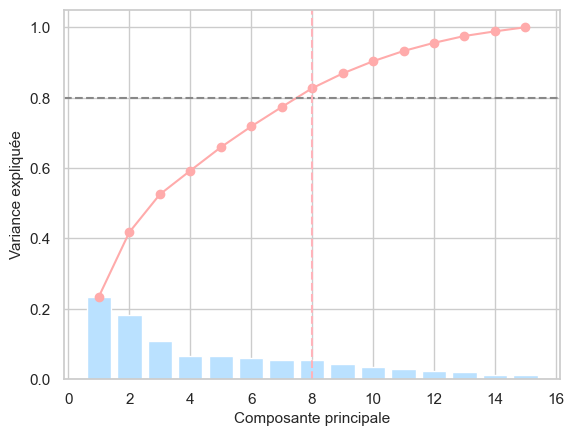

In [35]:
cumvar = np.cumsum(pca.explained_variance_ratio_)
n80 = np.argmax(cumvar >= 0.80) + 1
print(f"Composantes pour 80% de variance : {n80}")

plt.bar(range(1, len(pca.explained_variance_ratio_)+1), 
        pca.explained_variance_ratio_, color=PASTEL['bleu'])
plt.plot(range(1, len(cumvar)+1), cumvar, color=PASTEL['corail'], marker='o')
plt.axhline(0.80, color='#888', linestyle='--')
plt.axvline(n80, color=PASTEL['rose'], linestyle='--')
plt.xlabel("Composante principale")
plt.ylabel("Variance expliquée")
plt.show()

**ANALYSE** : Il faut 8 composantes pour expliquer 80% de la variance, ce qui indique que le jeu de données est multidimensionnel et qu'aucune variable ne domine seule la structure globale.

In [36]:
pc1 = X_pca[:, 0]
pc2 = X_pca[:, 1]

df_pca = pd.DataFrame()
df_pca['PC1'] = pc1
df_pca['PC2'] = pc2

df_pca['room_type'] = df['room_type'].values

unique_rooms = df_pca['room_type'].unique()
palette = {}

for i, room in enumerate(unique_rooms):
    palette[room] = ROOM_COLORS[i]

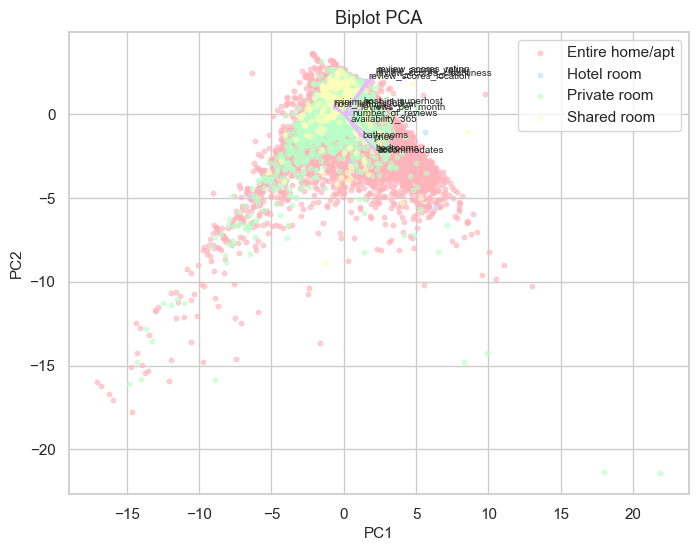

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))


for i, room in enumerate(sorted(df_pca['room_type'].unique())):
    sub = df_pca[df_pca['room_type'] == room]
    ax.scatter(sub['PC1'], sub['PC2'], color=ROOM_COLORS[i], s=10, alpha=0.6, label=room)


loadings = pca.components_[:2].T * 6
for i, feat in enumerate(features_num):
    ax.arrow(0, 0, loadings[i,0], loadings[i,1], color=PASTEL['violet'], head_width=0.1)
    ax.text(loadings[i,0]*1.1, loadings[i,1]*1.1, feat, fontsize=7)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Biplot PCA")
ax.legend()
plt.show()

In [ ]:
loadings_df = pd.DataFrame(
    pca.components_[:2].T,
    index=features_num,
    columns=['PC1', 'PC2']
)

print("Variance expliquée cumulée :")
cumvar = np.cumsum(pca.explained_variance_ratio_)
for i, cv in enumerate(cumvar):
    print(f"  PC{i+1}: {cv*100:.1f}%")
n_comp_80 = np.argmax(cumvar >= 0.80) + 1
print(f"{n_comp_80} composantes pour 80% de variance")

print("nTop contributeurs PC1 :")
top_pc1 = loadings_df['PC1'].abs().sort_values(ascending=False).head(3)
print(top_pc1.to_string())

print("Top contributeurs PC2 :")
top_pc2 = loadings_df['PC2'].abs().sort_values(ascending=False).head(3)
print(top_pc2.to_string())

Variance expliquée cumulée :
  PC1: 23.5%
  PC2: 41.8%
  PC3: 52.5%
  PC4: 59.2%
  PC5: 65.9%
  PC6: 71.8%
  PC7: 77.3%
  PC8: 82.7%
  PC9: 86.9%
  PC10: 90.3%
  PC11: 93.3%
  PC12: 95.6%
  PC13: 97.5%
  PC14: 98.8%
  PC15: 100.0%

→ 8 composantes pour 80% de variance

Top contributeurs PC1 :
accommodates            0.354716
review_scores_rating    0.350686
beds                    0.347997

Top contributeurs PC2 :
review_scores_rating         0.382006
review_scores_value          0.378806
review_scores_cleanliness    0.356447


**ANALYSE** PC1 est dominé par accommodates, review_scores_rating et beds c'est un axe taille/capacité du logement.
PC2 est dominé par review_scores_rating, review_scores_value et review_scores_cleanliness → c'est un axe qualité perçue par les voyageurs.

## 2.3 UMAP pour découverte de clusters
**Ce qu'on cherche** : révéler des structures non-linéaires que la PCA manque.

In [ ]:
import umap


reducer = umap.UMAP(n_components=2, random_state=SEED)
X_umap = reducer.fit_transform(X_scaled)

df_umap = pd.DataFrame({
    'UMAP1': X_umap[:,0],
    'UMAP2': X_umap[:,1],
    'room_type': df['room_type'],
    'superhost': df['host_is_superhost'].map({1:'Superhost',0:'Non-Superhost'}),
    'price_q': pd.qcut(df['price'], 4, labels=['Q1','Q2','Q3','Q4']),
    'neighbourhood': df['neighbourhood_cleansed']
})

print("UMAP calculé OK")

UMAP calculé OK


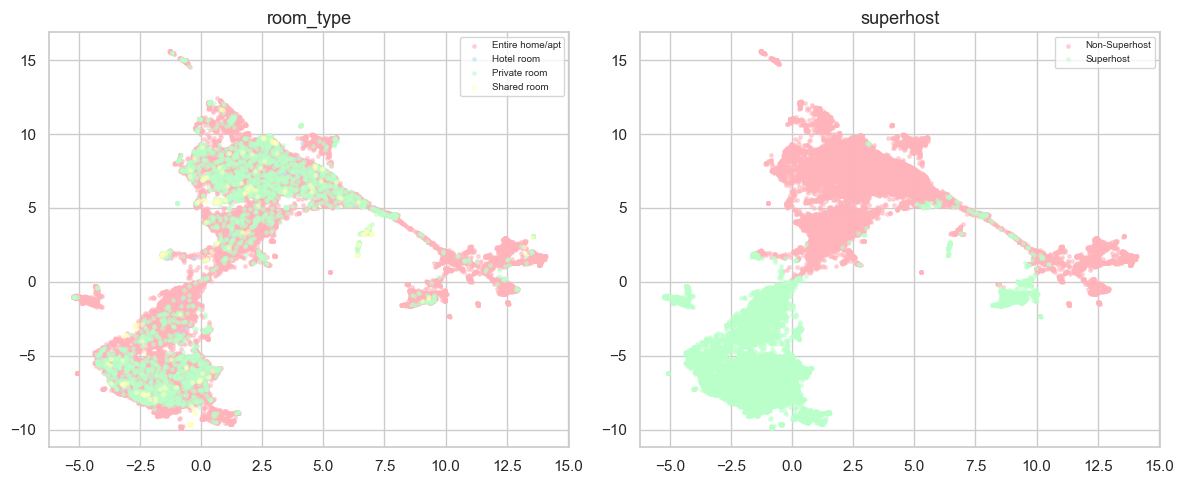

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (r, g) in enumerate(df_umap.groupby('room_type')):
    axes[0].scatter(g['UMAP1'], g['UMAP2'], color=ROOM_COLORS[i % len(ROOM_COLORS)], s=6, alpha=0.5, label=r)
axes[0].set_title("room_type")
axes[0].legend(fontsize=7)

for sh, g in df_umap.groupby('superhost'):
    axes[1].scatter(g['UMAP1'], g['UMAP2'], color=SH_COLORS[sh], s=6, alpha=0.5, label=sh)
axes[1].set_title("superhost")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

In [ ]:
print("Répartition room_type :")
print(df_umap['room_type'].value_counts().to_string())

print("Répartition superhost :")
print(df_umap['superhost'].value_counts().to_string())

print("Répartition prix par quartile :")
print(df_umap['price_q'].value_counts().sort_index().to_string())

Répartition room_type :
room_type
Entire home/apt    21841
Private room        3043
Shared room          254
Hotel room            87
Répartition superhost :
superhost
Non-Superhost    12841
Superhost        10543
Répartition prix par quartile :
price_q
Q1    6310
Q2    6303
Q3    6306
Q4    6306


**ANALYSE** : UMAP révèle deux clusters distincts (Superhost vs non-Superhost) que la PCA ne séparait pas, grâce à sa capacité à capturer les structures non-linéaires.

## 2.4 Visualisations spécialisées
### Ridgeline plot — distribution log(prix) par quartier
**Ce qu'on cherche** : comparer la distribution des prix entre quartiers, ordonnés par médiane.

In [42]:
from scipy.stats import gaussian_kde

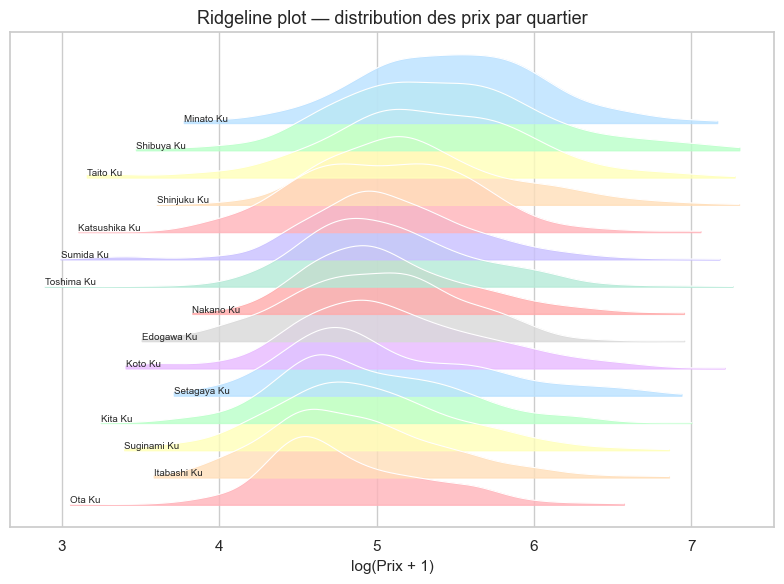

In [43]:
top_neigh = df['neighbourhood_cleansed'].value_counts().head(15).index
df_ridge = df[df['neighbourhood_cleansed'].isin(top_neigh)].copy()
df_ridge['log_price'] = np.log1p(df_ridge['price'])

ordre = df_ridge.groupby('neighbourhood_cleansed')['log_price'].median().sort_values().index

fig, ax = plt.subplots(figsize=(8, 6))

for i, neigh in enumerate(ordre):
    data = df_ridge.loc[df_ridge['neighbourhood_cleansed'] == neigh, 'log_price'].dropna()
    kde = gaussian_kde(data, bw_method=0.3)
    xs = np.linspace(data.min(), data.max(), 200)
    ys = kde(xs) / kde(xs).max() * 2.5
    ax.fill_between(xs, i, i + ys, color=PASTEL_LIST[i % len(PASTEL_LIST)], alpha=0.8)
    ax.plot(xs, i + ys, color='white', lw=0.8)
    ax.text(xs[0], i + 0.05, neigh, fontsize=7)

ax.set_yticks([])
ax.set_xlabel("log(Prix + 1)")
ax.set_title("Ridgeline plot — distribution des prix par quartier")
plt.tight_layout()
plt.show()

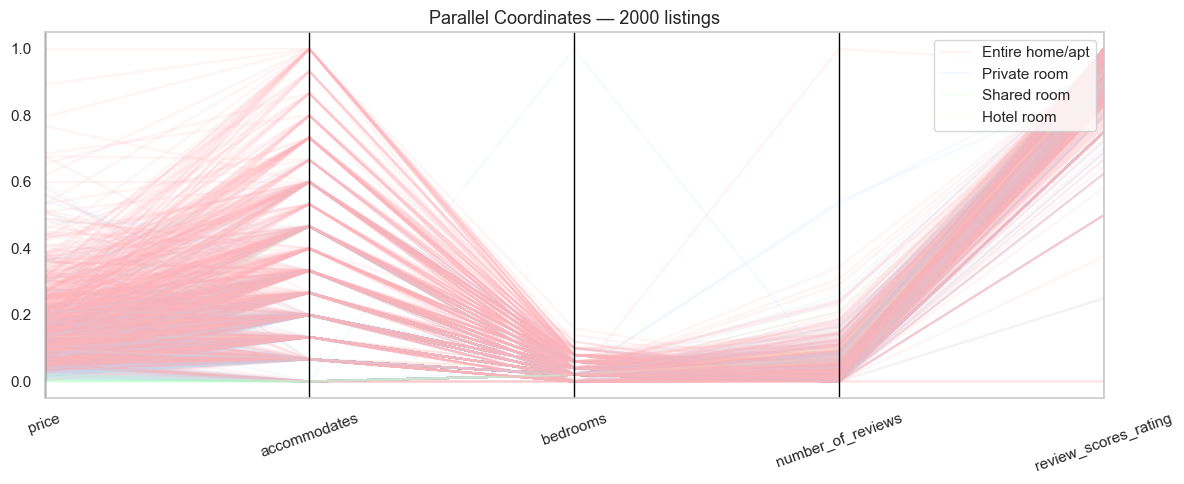

In [40]:
from pandas.plotting import parallel_coordinates

cols_key = ['price', 'accommodates', 'bedrooms', 'number_of_reviews', 'review_scores_rating', 'room_type']

df_para = df[cols_key].dropna().sample(2000, random_state=SEED).copy()


for c in cols_key[:-1]:
    df_para[c] = (df_para[c] - df_para[c].min()) / (df_para[c].max() - df_para[c].min())

fig, ax = plt.subplots(figsize=(12, 5))
parallel_coordinates(df_para, 'room_type', color=ROOM_COLORS, alpha=0.15, ax=ax)

ax.set_title("Parallel Coordinates — 2000 listings")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

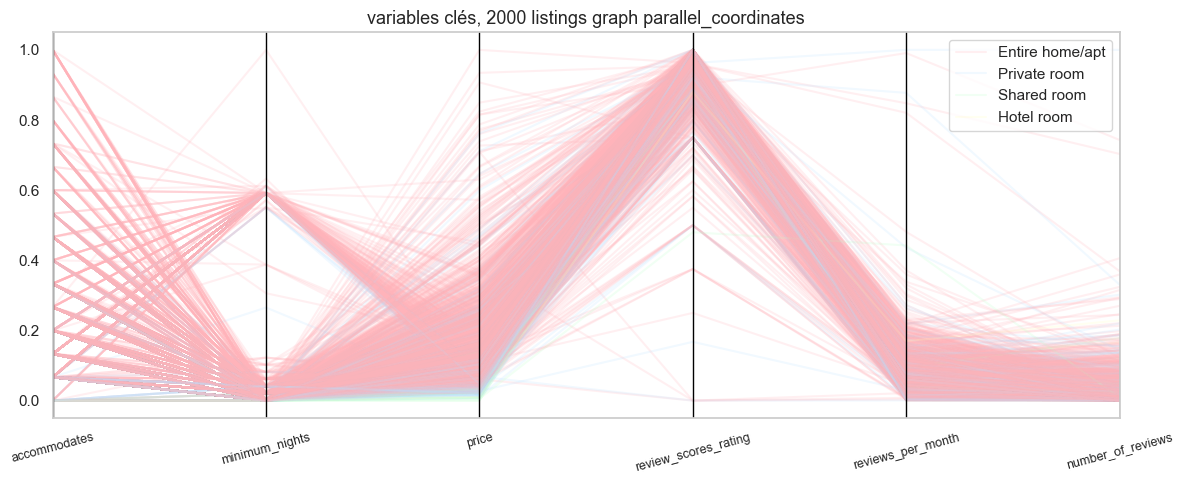

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

cols_key = ['accommodates', 'minimum_nights', 'price', 'review_scores_rating',
            'reviews_per_month', 'number_of_reviews', 'room_type']

df_para6 = df.sample(2000, random_state=SEED).copy()
df_para6 = df_para6[cols_key]

for col in cols_key[:-1]:
    df_para6[col] = df_para6[col].fillna(df_para6[col].median())
df_para6 = df_para6.dropna(subset=['room_type'])

for col in cols_key[:-1]:
    df_para6[col] = (df_para6[col] - df_para6[col].min()) / (df_para6[col].max() - df_para6[col].min())

plt.figure(figsize=(12, 5))
parallel_coordinates(df_para6, class_column='room_type', color=colors_fixed, alpha=0.2)

plt.title("variables clés, 2000 listings graph parallel_coordinates")
plt.xticks(rotation=15, fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
print("Répartition room_type dans l'échantillon :")
print(df_para['room_type'].value_counts().to_string())

Répartition room_type dans l'échantillon :
room_type
Entire home/apt    1728
Private room        250
Shared room          18
Hotel room            4


### Parallel coordinates — 2 000 listings colorés par room_type
**Ce qu'on cherche** : voir les patterns multivariés et les profils typiques par type de logement.

**ANALYSE** : Les Entire home sont plus grands et plus chers, toutes les notes sont très élevées, les Private rooms sont moins actives.


# Phase 3 — Relations non-linéaires et analyses multivariées
*Distance correlation, MIC, partial correlations, GAMs*

## 3.1 Comparaison de métriques de dépendance
**Ce qu'on cherche** : quantifier les relations non-linéaires que Pearson sous-estime.

In [ ]:
from scipy.stats import pearsonr, spearmanr
import numpy as np
import pandas as pd

def dist_corr(x, y):
    x, y = np.array(x), np.array(y)
    a = np.abs(x[:,None] - x[None,:])
    b = np.abs(y[:,None] - y[None,:])
    A = a - a.mean(0) - a.mean(1)[:,None] + a.mean()
    B = b - b.mean(0) - b.mean(1)[:,None] + b.mean()
    dcov2 = (A*B).mean(); dvar_x=(A*A).mean(); dvar_y=(B*B).mean()
    return np.sqrt(max(dcov2,0)/np.sqrt(dvar_x*dvar_y)) if dvar_x*dvar_y>0 else 0.0



paires = [('price','number_of_reviews'),
          ('price','review_scores_rating'),
          ('price','availability_365'),
          ('price','host_listings_count'),
          ('number_of_reviews','review_scores_rating')]

sub = df[['price','number_of_reviews','review_scores_rating',
          'availability_365','host_listings_count']].dropna().sample(2000, random_state=SEED)

res = []
for v1,v2 in paires:
    x, y = sub[v1], sub[v2]
    res.append({'Paire':f'{v1}~{v2}',
                'Pearson':pearsonr(x,y)[0],
                'Spearman':spearmanr(x,y)[0],
                'Dist.Corr':dist_corr(x,y)})

df_metrics = pd.DataFrame(res).set_index('Paire')
print(df_metrics.round(4))

                                        Pearson  Spearman  Dist.Corr
Paire                                                               
price~number_of_reviews                  0.0371    0.0526     0.0580
price~review_scores_rating               0.1637    0.2025     0.2141
price~availability_365                   0.1012    0.0817     0.1179
price~host_listings_count               -0.0947   -0.1282     0.1269
number_of_reviews~review_scores_rating   0.0305   -0.2371     0.2351


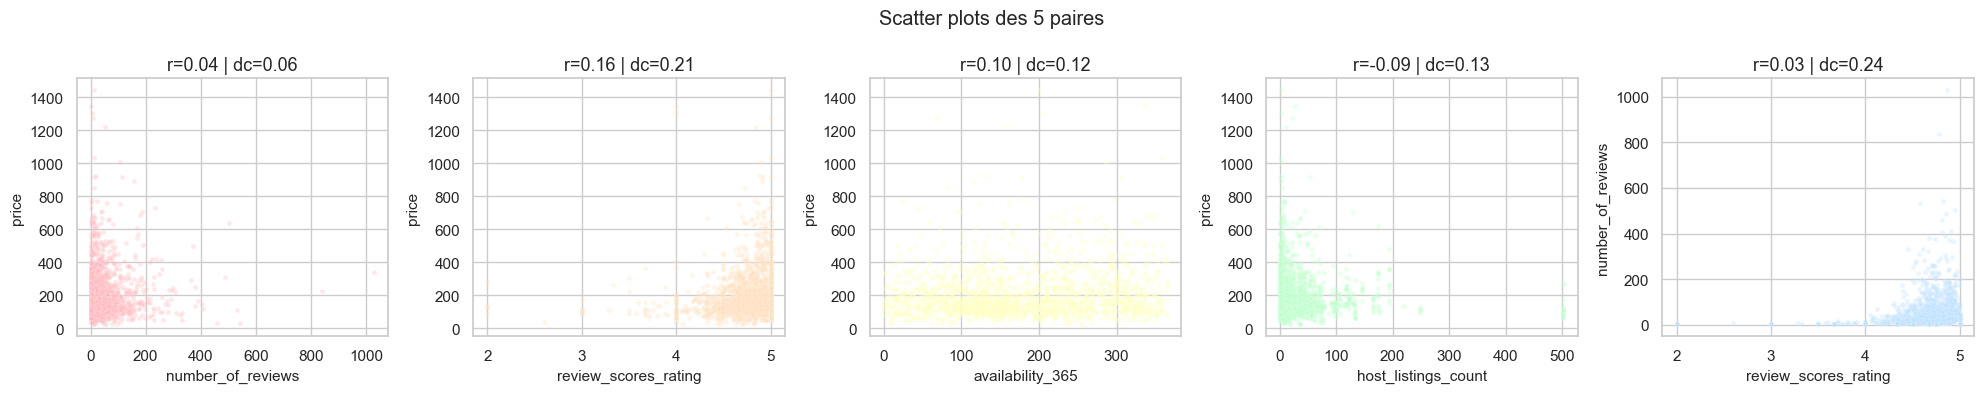

In [ ]:
fig, axes = plt.subplots(1, len(paires), figsize=(4*len(paires), 4))

for i in range(len(paires)):
    v1 = paires[i][0]
    v2 = paires[i][1]
    
    sns.scatterplot(x=sub[v2], y=sub[v1],
                    color=PASTEL_LIST[i % len(PASTEL_LIST)],
                    alpha=0.3, s=12, ax=axes[i])
    
    axes[i].set_xlabel(v2)
    axes[i].set_ylabel(v1)
    
    r = df_metrics.loc[f'{v1}~{v2}', 'Pearson']
    dc = df_metrics.loc[f'{v1}~{v2}', 'Dist.Corr']
    axes[i].set_title("r={:.2f} | dc={:.2f}".format(r, dc))

plt.suptitle("Scatter plots des 5 paires")
plt.tight_layout()
plt.show()

**ANALYSE** Pearson sous-estime surtout number_of_reviews ~ review_scores_rating et price ~ review_scores_rating car ces relations sont non-linéaires — les autres paires n'ont tout simplement pas de relation significative.

## 3.2 Corrélations partielles
**Ce qu'on cherche** : mesurer ce qui reste de la relation avis/prix une fois les confounders contrôlés.

In [46]:
from scipy.stats import pearsonr, spearmanr

def dist_corr(x, y):
    x = np.array(x)
    y = np.array(y)
    a = np.abs(x[:,None] - x[None,:])
    b = np.abs(y[:,None] - y[None,:])
    A = a - a.mean()
    B = b - b.mean()
    dcov = (A * B).mean()
    dvar_x = (A * A).mean()
    dvar_y = (B * B).mean()
    return np.sqrt(dcov / np.sqrt(dvar_x * dvar_y))

sub = df[['price','number_of_reviews','review_scores_rating','availability_365','host_listings_count']].dropna().sample(2000, random_state=SEED)

paires = [('price','number_of_reviews'),
          ('price','review_scores_rating'),
          ('price','availability_365'),
          ('price','host_listings_count'),
          ('number_of_reviews','review_scores_rating')]

for v1, v2 in paires:
    x = sub[v1]
    y = sub[v2]
    p = pearsonr(x, y)[0]
    s = spearmanr(x, y)[0]
    d = dist_corr(x, y)
    print(f"{v1} ~ {v2}")
    print(f"  Pearson={p:.3f}  Spearman={s:.3f}  DistCorr={d:.3f}")
    print()

price ~ number_of_reviews
  Pearson=0.037  Spearman=0.053  DistCorr=0.178

price ~ review_scores_rating
  Pearson=0.164  Spearman=0.203  DistCorr=nan



C:\Users\LEOPO\AppData\Local\Temp\ipykernel_39708\457148933.py:13: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(dcov / np.sqrt(dvar_x * dvar_y))


price ~ availability_365
  Pearson=0.101  Spearman=0.082  DistCorr=0.143

price ~ host_listings_count
  Pearson=-0.095  Spearman=-0.128  DistCorr=nan

number_of_reviews ~ review_scores_rating
  Pearson=0.030  Spearman=-0.237  DistCorr=nan



In [ ]:
def resid(serie, controle):
    from numpy.linalg import lstsq
    X = pd.get_dummies(controle, drop_first=True).astype(float)
    X['const'] = 1
    coef, _, _, _ = lstsq(X, serie, rcond=None)
    return serie - X.values @ coef

sub = df[['number_of_reviews', 'price', 'room_type', 'neighbourhood_cleansed']].dropna()

#
r_brut = sub['number_of_reviews'].corr(sub['price'])

r_ctrl_room = resid(sub['number_of_reviews'], sub['room_type']).corr(
              resid(sub['price'], sub['room_type']))

r_ctrl_neigh = resid(sub['number_of_reviews'], sub['neighbourhood_cleansed']).corr(
               resid(sub['price'], sub['neighbourhood_cleansed']))

both = sub[['room_type', 'neighbourhood_cleansed']]
r_ctrl_both = resid(sub['number_of_reviews'], both).corr(
              resid(sub['price'], both))

print(r_brut, r_ctrl_room, r_ctrl_neigh, r_ctrl_both)

0.02811045652903137 0.03664326702893859 0.01368647657661627 0.02121703480175919


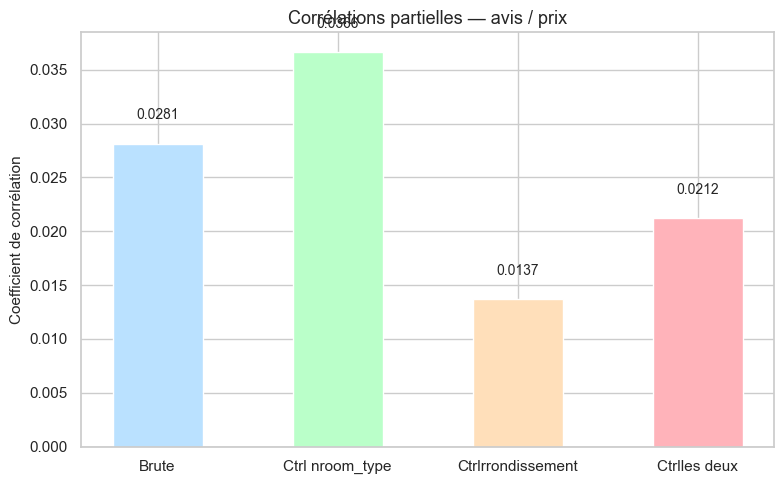

In [51]:
labels   = ['Brute','Ctrl nroom_type','Ctrlrrondissement','Ctrlles deux']
valeurs  = [r_brut, r_ctrl_room, r_ctrl_neigh, r_ctrl_both]
couleurs = [PASTEL['bleu'], PASTEL['vert'], PASTEL['peche'], PASTEL['rose']]

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(labels, valeurs, color=couleurs, edgecolor='white', width=0.5)
ax.axhline(0, color='#555', linewidth=0.8)
for bar, val in zip(bars, valeurs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.002*np.sign(val),
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel("Coefficient de corrélation")
ax.set_title("Corrélations partielles — avis / prix")
plt.tight_layout(); plt.show()


**ANALYSE** : La corrélation entre nombre d'avis et prix est quasi nulle dans tous les cas (r < 0.04), et diminue encore une fois l'arrondissement contrôlé (r=0.014) — il n'existe pas de lien direct entre ces deux variables.

## 3.3 GAM — Modélisation non-linéaire
**Ce qu'on cherche** : capturer les relations non-linéaires entre log(prix) et les features continues.

In [52]:
from pygam import LinearGAM, s, f

LAT, LON = 35.6762, 139.6503
df['dist'] = np.sqrt(
    ((df['latitude'] - LAT) * 111)**2 +
    ((df['longitude'] - LON) * 111)**2
)


df_gam = df[['price','dist','number_of_reviews','review_scores_rating','room_type']].dropna()
df_gam = df_gam[df_gam['price'] > 0].copy()
df_gam['log_price'] = np.log(df_gam['price'])
df_gam['room_code'] = df_gam['room_type'].astype('category').cat.codes

X = df_gam[['dist','number_of_reviews','review_scores_rating','room_code']].values
y = df_gam['log_price'].values

gam = LinearGAM(s(0) + s(1) + s(2) + f(3)).fit(X, y)
print("Pseudo R2:", gam.statistics_['pseudo_r2'])

Pseudo R2: OrderedDict([('explained_deviance', 0.1716883791620828), ('McFadden', 0.887495450272181), ('McFadden_adj', 0.11071606701020897)])


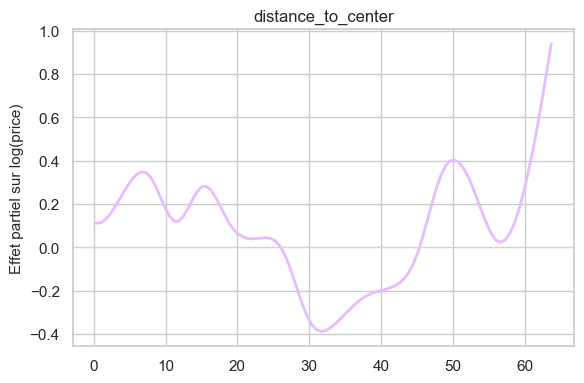

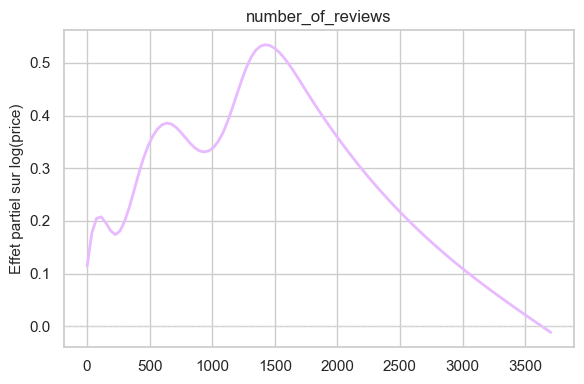

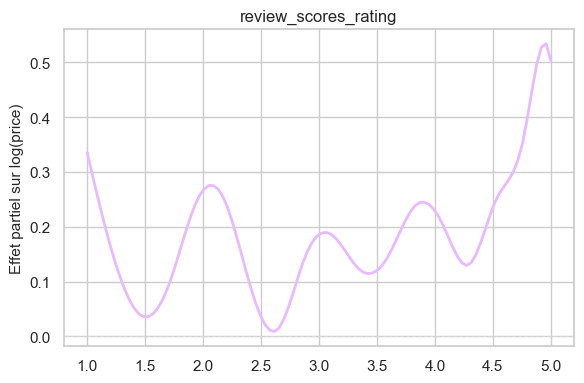

Prix chute après: 63.67734881941958
Volume d'avis optimal: 1422.7373737373737


In [53]:
titles = ['distance_to_center', 'number_of_reviews', 'review_scores_rating']

for i in [0, 1, 2]:
    XX = gam.generate_X_grid(term=i)
    pdp = gam.partial_dependence(term=i, X=XX)
    plt.figure(figsize=(6, 4))
    plt.plot(XX[:, i], pdp, color=PASTEL['violet'], lw=2)
    plt.axhline(0, color=PASTEL['gris'], linestyle='--', lw=0.8)
    plt.title(titles[i], fontsize=12)
    plt.ylabel("Effet partiel sur log(price)")
    plt.tight_layout()
    plt.show()

X0 = gam.generate_X_grid(term=0)
pdp0 = gam.partial_dependence(term=0, X=X0)
print("Prix chute après:", X0[pdp0.argmax(), 0])

X1 = gam.generate_X_grid(term=1)
pdp1 = gam.partial_dependence(term=1, X=X1)
print("Volume d'avis optimal:", X1[pdp1.argmax(), 1])

**ANALYSE** : Distance : le prix varie  sans tendance claire — grosse  baisse vers 22 km mais remonte, puis remonte apres 50 km
Nombre d'avis : effet positif jusqu'à ~1500 avis puis décroit — le volume optimal est autour de 1500 avis.
aucune relation fiable entre note et prix.

---
# Phase 4 — Temporel et spatial
*STL, changepoints, Moran's I, LISA, calendar heatmap*

## 4.1 Série temporelle mensuelle des avis
**Ce qu'on cherche** : décomposer la tendance, la saisonnalité et les anomalies de l'activité Airbnb.

In [55]:
import pandas as pd

reviews = pd.read_csv('./Data/reviews.csv', parse_dates=['date'], usecols=['listing_id','date'])
monthly = reviews.set_index('date').resample('ME').size()

print(monthly.tail())
print("Période :", monthly.index.min(), "→", monthly.index.max())

date
2025-05-31    35574
2025-06-30    31531
2025-07-31    31152
2025-08-31    30211
2025-09-30    26489
Freq: ME, dtype: int64
Période : 2011-09-30 00:00:00 → 2025-09-30 00:00:00


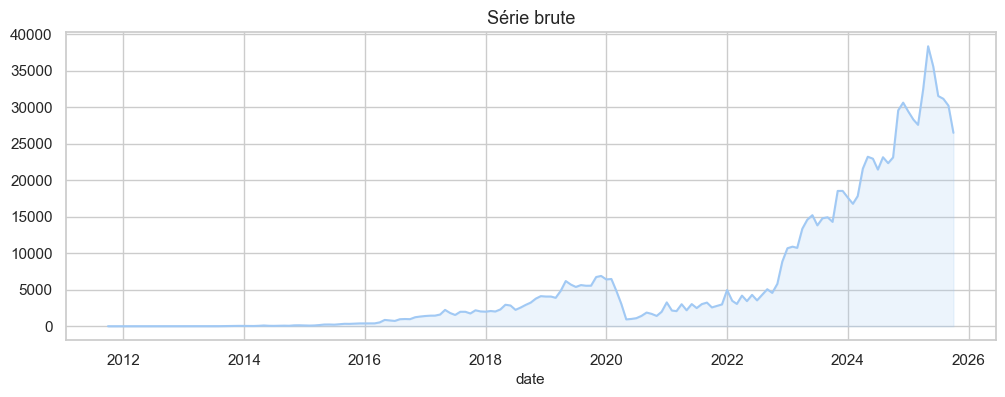

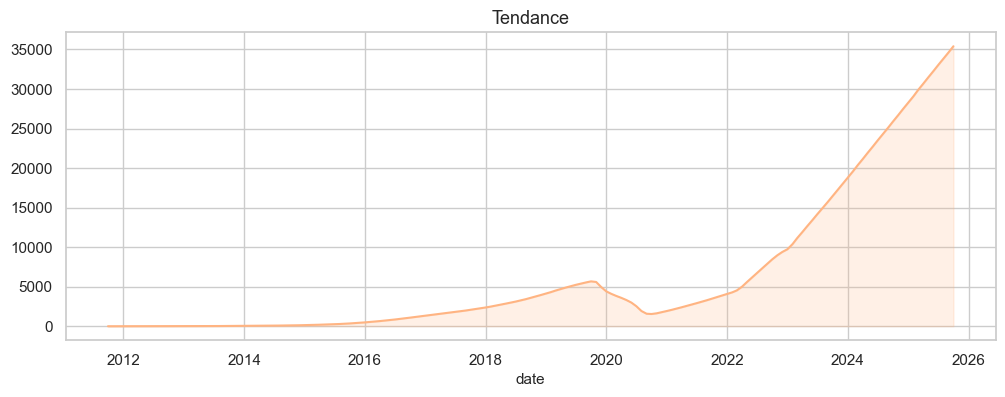

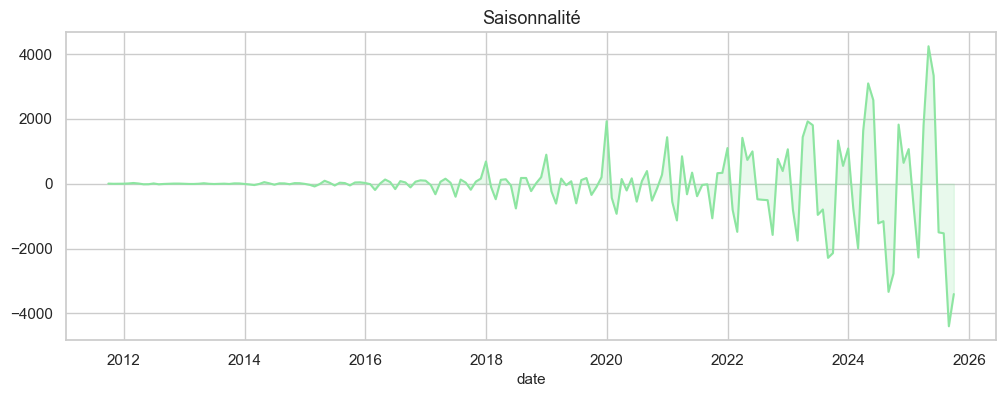

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

stl = STL(monthly, period=12, robust=True).fit()
colors = sns.color_palette('pastel', 3)

plt.figure(figsize=(12,4))
sns.lineplot(x=monthly.index, y=monthly.values, color=colors[0])
plt.fill_between(monthly.index, monthly.values, alpha=0.2, color=colors[0])
plt.title("Série brute")
plt.show()

plt.figure(figsize=(12,4))
sns.lineplot(x=stl.trend.index, y=stl.trend.values, color=colors[1])
plt.fill_between(stl.trend.index, stl.trend.values, alpha=0.2, color=colors[1])
plt.title("Tendance")
plt.show()

plt.figure(figsize=(12,4))
sns.lineplot(x=stl.seasonal.index, y=stl.seasonal.values, color=colors[2])
plt.fill_between(stl.seasonal.index, stl.seasonal.values, alpha=0.2, color=colors[2])
plt.title("Saisonnalité")
plt.show()

**ANALYSE** : On note une forte évolution de la saisonnalité après 2020, probablement liée à la reprise post-COVID.

### Détection de changepoints (PELT)
**Ce qu'on cherche** : dater les ruptures structurelles dans la série.

Changepoints : [Timestamp('2017-03-31 00:00:00'), Timestamp('2022-10-31 00:00:00')]


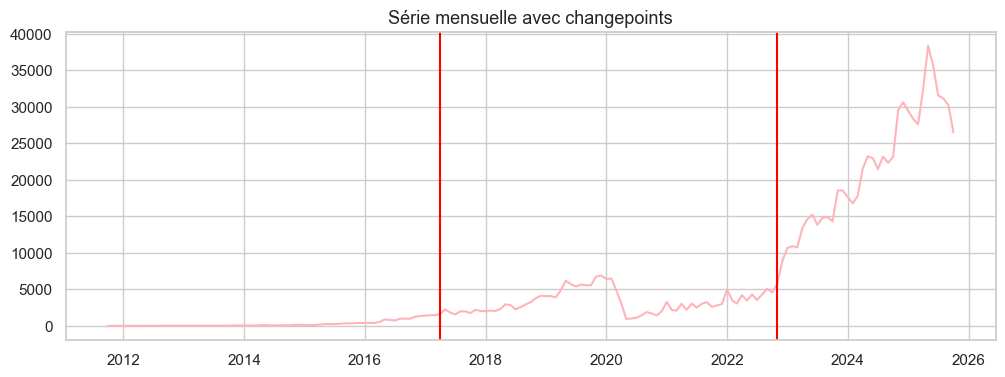

In [56]:
import ruptures as rpt
import matplotlib.pyplot as plt

signal = monthly.values.astype(float)
algo = rpt.Pelt(model='rbf', min_size=3, jump=1).fit(signal)
bkps = algo.predict(pen=10)
dates_bkps = [monthly.index[b-1] for b in bkps[:-1]]
print("Changepoints :", dates_bkps)

plt.figure(figsize=(12,4))
plt.plot(monthly.index, monthly.values)
for d in dates_bkps:
    plt.axvline(d, color='red', linestyle='-')
plt.title("Série mensuelle avec changepoints")
plt.show()

**ANALYSE** : Tendance : croissance en deux temps 2018-2020 puis 2022-2026 avec un creux marqué dû au COVID.
Saisonnalité : pics estivaux suivis de chutes importantes, la fluctuation s'amplifie avec le temps et devient très instable post-2023.
Changepoints : un avant COVID (2017, décollage du marché) et un après (oct. 2022, réouverture du Japon) la période COVID a clairement cassé la dynamique et retardé la croissance de ~2 ans.

## 4.2 Autocorrélation temporelle
**Ce qu'on cherche** : tester la stationnarité et identifier la structure ARMA latente.

In [58]:
from statsmodels.tsa.stattools import adfuller, kpss

adf = adfuller(monthly.dropna())
kpss_res = kpss(monthly.dropna(), regression='c', nlags='auto')

print("ADF p-value :", round(adf[1], 4))
print("KPSS p-value :", round(kpss_res[1], 4))

ADF p-value : 0.8283
KPSS p-value : 0.01


C:\Users\LEOPO\AppData\Local\Temp\ipykernel_39708\202627652.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(monthly.dropna(), regression='c', nlags='auto')


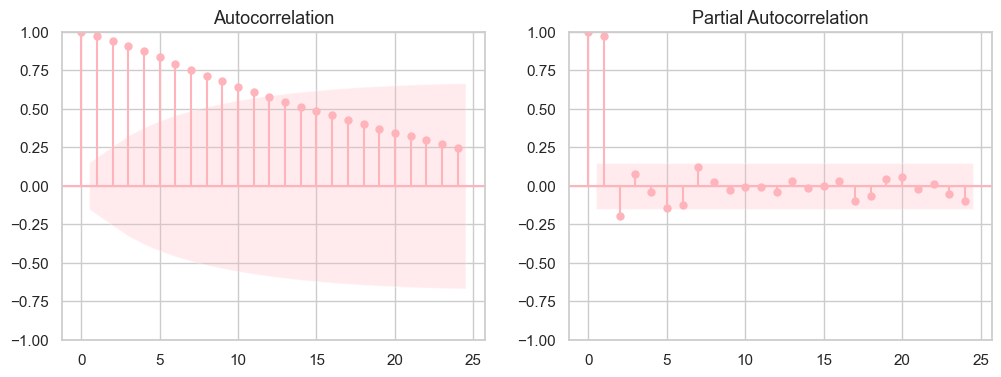

ADF p-value : 0.8283
KPSS p-value : 0.01


C:\Users\LEOPO\AppData\Local\Temp\ipykernel_39708\3924094968.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(monthly.dropna(), regression='c', nlags='auto')


In [59]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(monthly, lags=24, ax=axes[0])
plot_pacf(monthly, lags=24, ax=axes[1])
plt.show()
adf = adfuller(monthly.dropna())
kpss_res = kpss(monthly.dropna(), regression='c', nlags='auto')

print("ADF p-value :", round(adf[1], 4))
print("KPSS p-value :", round(kpss_res[1], 4))

**ANALYSE** : ACF décroît lentement → non stationnaire. PACF coupe après lag 1 → AR(1). Différenciation d=1 nécessaire, confirmée par ADF+KPSS.

## 4.3 Autocorrélation spatiale des prix (Moran's I)
**Ce qu'on cherche** : les arrondissements aux prix similaires se regroupent-ils géographiquement ?

In [ ]:
gdf = gpd.read_file('./Data/neighbourhoods.geojson')
print(gdf.head())
print(gdf.geometry.is_valid.value_counts())

   neighbourhood neighbourhood_group  \
0     Edogawa Ku                None   
1   Mizuho Machi                None   
2  Katsushika Ku                None   
3   Shinagawa Ku                None   
4        Koto Ku                None   

                                            geometry  
0  MULTIPOLYGON (((139.8578 35.6358, 139.8553 35....  
1  MULTIPOLYGON (((139.32091 35.7772, 139.32359 3...  
2  MULTIPOLYGON (((139.8468 35.79653, 139.8564 35...  
3  MULTIPOLYGON (((139.7728 35.5956, 139.7668 35....  
4  MULTIPOLYGON (((139.8212 35.63413, 139.8204 35...  
True    62
Name: count, dtype: int64


In [60]:
import geopandas as gpd
import numpy as np
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local

gdf = gpd.read_file('./Data/neighbourhoods.geojson')
gdf['geometry'] = gdf['geometry'].buffer(0)
gdf = gdf[gdf.geometry.notnull() & ~gdf.geometry.is_empty & gdf.geometry.is_valid]
gdf = gdf.reset_index(drop=True)

prix_med = df.groupby('neighbourhood_cleansed')['price'].median()
gdf['log_prix'] = np.log1p(gdf['neighbourhood'].map(prix_med))
gdf = gdf.dropna(subset=['log_prix']).reset_index(drop=True)

print("Quartiers valides:", len(gdf))

w = Queen.from_dataframe(gdf)
w.transform = 'r'

mi = Moran(gdf['log_prix'], w)
print(f"Moran I = {mi.I:.4f}, p = {mi.p_sim:.4f}")

lm = Moran_Local(gdf['log_prix'], w)
gdf['LISA'] = pd.Series(lm.q).map({1:'HH', 2:'LH', 3:'LL', 4:'HL'})
gdf['LISA_sig'] = lm.p_sim < 0.05

print(gdf[['neighbourhood', 'log_prix', 'LISA', 'LISA_sig']].head(10))

c:\HETIC\2025-2026\EDA Visualisation\env_eda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\LEOPO\AppData\Local\Temp\ipykernel_39708\3513665712.py:17: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


Quartiers valides: 49
Moran I = 0.4764, p = 0.0010
       neighbourhood  log_prix LISA  LISA_sig
0         Edogawa Ku  4.994641   HH     False
1      Katsushika Ku  5.046678   HH     False
2       Shinagawa Ku  4.961655   HH     False
3            Koto Ku  4.983264   HH      True
4  Higashiyamato Shi  3.958143   LL      True
5         Chiyoda Ku  5.414944   HH      True
6          Minato Ku  5.477216   HH      True
7          Komae Shi  5.037342   HL     False
8            Chuo Ku  5.536783   HH      True
9          Fussa Shi  4.773984   LL     False


In [62]:
import folium

In [61]:
import geopandas as gpd
from libpysal.weights import KNN
from esda.moran import Moran, Moran_Local

gdf = gpd.read_file('./Data/neighbourhoods.geojson').to_crs(epsg=3857)
gdf['geometry'] = gdf['geometry'].buffer(10).buffer(-10)
gdf = gdf[gdf.geometry.notnull() & ~gdf.geometry.is_empty & gdf.geometry.is_valid].reset_index(drop=True)

prix_median = df.groupby('neighbourhood_cleansed')['price'].median()
gdf['log_prix'] = gdf['neighbourhood'].map(prix_median).pipe(np.log1p)
gdf = gdf.dropna(subset=['log_prix']).reset_index(drop=True)
print("Quartiers valides :", len(gdf))

w = KNN.from_dataframe(gdf, k=5)
w.transform = 'r'

moran_global = Moran(gdf['log_prix'], w)
print(f"Moran I = {moran_global.I:.4f}, p = {moran_global.p_sim:.4f}")

moran_local = Moran_Local(gdf['log_prix'], w)
gdf['LISA'] = pd.Series(moran_local.q).map({1:'HH', 2:'LH', 3:'LL', 4:'HL'})
gdf['LISA_sig'] = moran_local.p_sim < 0.05

print(gdf[['neighbourhood', 'log_prix', 'LISA', 'LISA_sig']].head(10))

Quartiers valides : 49
Moran I = 0.3614, p = 0.0010
       neighbourhood  log_prix LISA  LISA_sig
0         Edogawa Ku  4.994641   HH      True
1      Katsushika Ku  5.046678   HH     False
2       Shinagawa Ku  4.961655   HH      True
3            Koto Ku  4.983264   HH      True
4  Higashiyamato Shi  3.958143   LL     False
5         Chiyoda Ku  5.414944   HH      True
6          Minato Ku  5.477216   HH      True
7          Komae Shi  5.037342   HL     False
8            Chuo Ku  5.536783   HH      True
9          Fussa Shi  4.773984   LL      True


In [ ]:
gdf_wgs = gdf.to_crs(epsg=4326)

lisa_colors = {
    'HH': PASTEL['corail'],
    'LH': PASTEL['bleu'],
    'LL': PASTEL['lavande'],
    'HL': PASTEL['peche']
}

m = folium.Map(location=[35.6762, 139.6503], zoom_start=10, tiles='CartoDB positron')

folium.Choropleth(
    geo_data=gdf_wgs,
    data=gdf_wgs,
    columns=['neighbourhood', 'log_prix'],
    key_on='feature.properties.neighbourhood',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name='log(prix médian)'
).add_to(m)

folium.GeoJson(
    gdf_wgs[gdf_wgs['LISA_sig']],
    name='LISA',
    style_function=lambda f: {
        'fillColor': lisa_colors.get(f['properties']['LISA'], PASTEL['gris']),
        'color': 'white',
        'weight': 1,
        'fillOpacity': 0.8
    },
    tooltip=folium.GeoJsonTooltip(fields=['neighbourhood', 'LISA', 'log_prix'])
).add_to(m)

folium.LayerControl().add_to(m)
m.save('carte_lisa.html')

Problème de confiance (trust) avec ce librairie  sinon la carte est enregistré au format html dans le dossier final du projet

**ANALYSE** : Prix élevés au centre-est (Chiyoda, Minato), faibles à l'ouest — structure centre-périphérie confirmée par Moran I = 0.36.

## 4.4 Calendar Heatmap
**Ce qu'on cherche** : visualiser les cycles saisonniers et repérer les ruptures jour par jour.

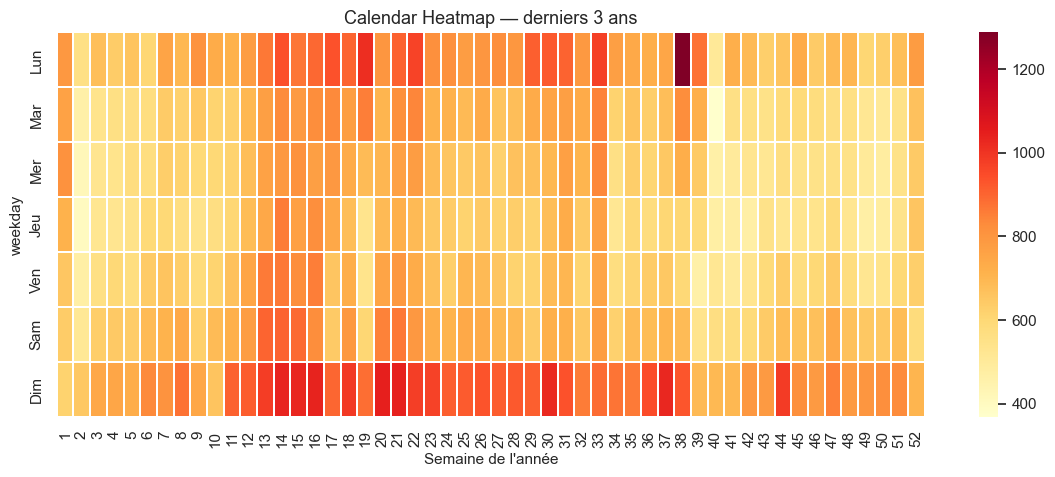

In [64]:
daily = reviews.set_index('date').resample('D').size().rename('n_reviews')
last3 = daily[daily.index >= daily.index.max() - pd.DateOffset(years=3)]

df = last3.reset_index()
df['week'] = df['date'].dt.isocalendar().week
df['weekday'] = df['date'].dt.weekday

pivot = df.pivot_table(index='week', columns='weekday', values='n_reviews', fill_value=0)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
sns.heatmap(pivot.T, cmap='YlOrRd', linecolor='white', linewidths=0.3)
plt.yticks([0.5,1.5,2.5,3.5,4.5,5.5,6.5], ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim'])
plt.xlabel("Semaine de l'année")
plt.title("Calendar Heatmap — derniers 3 ans")
plt.show()

**ANALYSE** : Activité peak en semaines 19-30 (mai-juillet), dimanches et lundis concentrent nettement plus d'avis que le reste de la semaine. Gros creux de la semaine 40 à 52 (automne-hiver). Le lundi semaine 39 affiche un pic isolé >1200 — anomalie ponctuelle probable.